In [1]:
## Imports

In [2]:
import scanpy as sc
import numpy as np
import scipy as sp
import os, sys
from pathlib import Path
_p = Path(".").resolve()
while not (_p / "src" / "config.py").exists() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))
from src.config import ANALYSIS_DIR, DATA_DIR


In [4]:
d4_as = sc.read_h5ad(DATA_DIR / "data-objects/raw/egfDuod_D4_AS_DZ.h5ad")

In [5]:
d4_as

AnnData object with n_obs × n_vars = 64956 × 27680
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident'
    uns: 'X_name'
    layers: 'counts'

In [6]:
d4_as.var["mt"] = d4_as.var_names.str.startswith("MT-")

In [7]:
d4_as

AnnData object with n_obs × n_vars = 64956 × 27680
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident'
    var: 'mt'
    uns: 'X_name'
    layers: 'counts'

In [8]:
d4_as.var["ribo"] = d4_as.var_names.str.startswith(("RPS", "RPL"))


In [9]:
sc.pp.calculate_qc_metrics(d4_as, qc_vars=["mt", "ribo"], inplace=True, log1p=True)

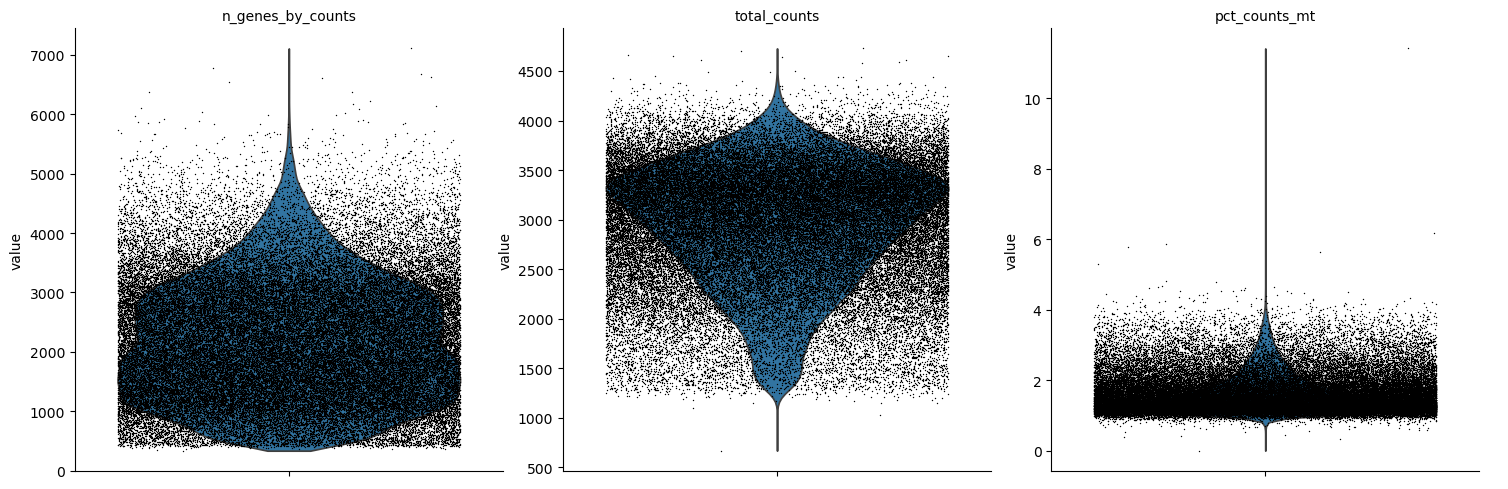

In [10]:
sc.pl.violin(
    d4_as,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

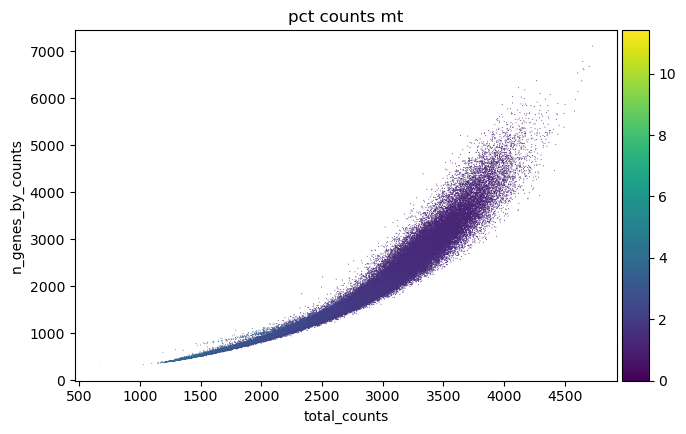

In [11]:
sc.pl.scatter(d4_as, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [12]:
d4_as.obs[['n_genes_by_counts','total_counts','pct_counts_mt']].describe()


,n_genes_by_counts,total_counts,pct_counts_mt
count,64956.000000,64956.000000,64956.000000
mean,2186.125531,2932.171402,1.618159
std,1015.397558,616.381990,0.565265
min,334.000000,667.399868,0.000000
25%,1370.750000,2529.155419,1.219108
50%,2103.000000,3033.590309,1.437080
75%,2907.000000,3394.688070,1.847732
max,7110.000000,4727.644093,11.414587


In [13]:
sc.pp.scrublet(d4_as)

In [14]:
d4_as

AnnData object with n_obs × n_vars = 64956 × 27680
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'X_name', 'scrublet'
    layers: 'counts'

In [15]:
d4_as.obs[['doublet_score']].describe()


,doublet_score
count,64956.000000
mean,0.129783
std,0.088375
min,0.002557
25%,0.061307
50%,0.108658
75%,0.180000
max,0.665493


In [16]:
d4_as.obs[['predicted_doublet']].describe()


,predicted_doublet
count,64956
unique,1
top,False
freq,64956


In [17]:
## we need to set the parameter for the threshold of 'predicted doublet', we're failing to do so manually

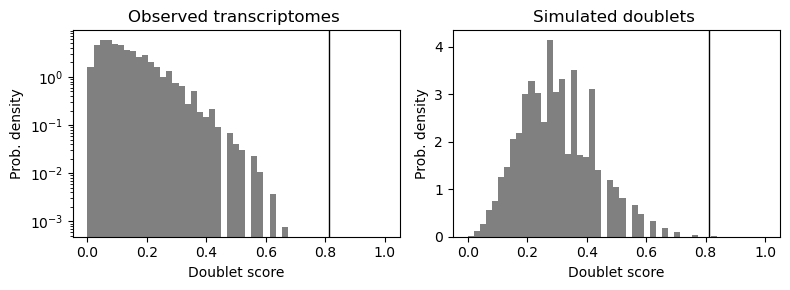

In [18]:
sc.pl.scrublet_score_distribution(d4_as)

In [19]:
intermediate_directory = str(ANALYSIS_DIR / "data-objects/qc")
sc.write(f'{intermediate_directory}/doublet_egfDuod_D4_AS_DZ.h5ad', d4_as)